In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [157]:
#load dataset
df=pd.read_csv(r"C:\Users\LENOVO T480\Downloads\beginner_scikit_learn_loan_default.csv")

In [158]:
#check first few 10
df.head(10)

,customer_id,age,monthly_income_ksh,employment_years,credit_score,loan_amount_ksh,loan_term_months,existing_loans,late_payments_last_12m,debt_to_income_ratio,savings_ksh,dependents,employment_type,education_level,housing_status,loan_default
0,CUST10001,23,101577.0,17.2,567.0,128700.0,24,2,0,0.64,22900.0,5,Salaried,Diploma,Rent,1
1,CUST10002,49,107972.0,4.1,732.0,109800.0,36,3,1,0.38,31300.0,3,Salaried,Degree,Family,1
2,CUST10003,55,41551.0,3.5,672.0,245700.0,36,1,0,0.29,108400.0,4,Salaried,Diploma,Own,0
3,CUST10004,59,66605.0,7.8,732.0,159200.0,12,1,5,0.18,45200.0,4,Salaried,Degree,Rent,1
4,CUST10005,38,46412.0,4.7,589.0,178300.0,24,2,0,0.33,69900.0,3,Salaried,Secondary,Family,1
5,CUST10006,40,184613.0,7.7,672.0,109500.0,36,0,0,0.57,140000.0,1,Salaried,Degree,Rent,1
6,CUST10007,63,109897.0,2.1,751.0,201800.0,24,1,0,0.58,54800.0,3,Self-employed,Degree,Family,0
7,CUST10008,43,30433.0,7.1,767.0,96100.0,24,0,0,0.26,56700.0,3,Salaried,Diploma,NaN,0
8,CUST10009,54,34657.0,14.6,699.0,310100.0,6,0,1,0.32,88800.0,4,Salaried,Secondary,Own,1
9,CUST10010,53,36900.0,10.7,707.0,186400.0,24,0,0,0.29,82800.0,0,Self-employed,Diploma,Own,1


In [159]:
#check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1212 non-null   object 
 1   age                     1212 non-null   int64  
 2   monthly_income_ksh      1188 non-null   float64
 3   employment_years        1193 non-null   float64
 4   credit_score            1194 non-null   float64
 5   loan_amount_ksh         1212 non-null   float64
 6   loan_term_months        1212 non-null   int64  
 7   existing_loans          1212 non-null   int64  
 8   late_payments_last_12m  1212 non-null   int64  
 9   debt_to_income_ratio    1212 non-null   float64
 10  savings_ksh             1212 non-null   float64
 11  dependents              1212 non-null   int64  
 12  employment_type         1212 non-null   object 
 13  education_level         1194 non-null   object 
 14  housing_status          1194 non-null   

In [160]:
#describe dataset
df.describe()

,age,monthly_income_ksh,employment_years,credit_score,loan_amount_ksh,loan_term_months,existing_loans,late_payments_last_12m,debt_to_income_ratio,savings_ksh,dependents,loan_default
count,1212.000000,1188.000000,1193.000000,1194.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1.212000e+03,1212.000000,1212.000000
mean,43.074257,66174.572391,7.384661,651.643216,183305.033003,22.178218,1.075083,0.868812,0.356205,1.091431e+05,2.476073,0.629538
std,13.030020,31221.873328,4.663874,58.646254,98679.062655,10.932172,1.029767,0.956589,0.123721,1.120026e+05,1.699154,0.483128
min,-2.000000,13857.000000,0.000000,-10.000000,33800.000000,6.000000,0.000000,0.000000,-0.100000,8.700000e+03,0.000000,0.000000
25%,32.000000,43922.750000,3.800000,615.000000,110575.000000,12.000000,0.000000,0.000000,0.280000,5.017500e+04,1.000000,0.000000
50%,43.000000,59453.500000,7.400000,653.000000,164650.000000,24.000000,1.000000,1.000000,0.360000,8.115000e+04,3.000000,1.000000
75%,54.000000,82203.750000,10.700000,687.750000,225750.000000,24.000000,2.000000,1.000000,0.430000,1.364000e+05,4.000000,1.000000
max,90.000000,287047.000000,24.400000,850.000000,782200.000000,48.000000,6.000000,5.000000,1.500000,2.380000e+06,5.000000,1.000000


In [161]:
#check the sum of nulls
df.isnull().sum()

customer_id                0
age                        0
monthly_income_ksh        24
employment_years          19
credit_score              18
loan_amount_ksh            0
loan_term_months           0
existing_loans             0
late_payments_last_12m     0
debt_to_income_ratio       0
savings_ksh                0
dependents                 0
employment_type            0
education_level           18
housing_status            18
loan_default               0
dtype: int64

In [162]:
#check the shape
df.shape


(1212, 16)

In [163]:
#cleaning the dataset
#1. dropping duplicates
df=df.drop_duplicates()

In [164]:
#2.Removing unrealistic age values
df=df[(df["age"])>0 & (df["age"]<=100)]

In [165]:
#3.Standardising the "nan"
df["employment_years"]=df["employment_years"].replace({"nan":np.nan})

In [166]:
#4.Removing unrealistic credit_score values
df=df[(df["credit_score"])>0]

In [167]:
#5.Removing unrealistic values in debt_to_income_ratio
df=df[(df["debt_to_income_ratio"])>0.00]

In [168]:
#6.standardising the text format
df["employment_type"]=df["employment_type"].astype(str)
df["employment_type"]=df["employment_type"].str.strip()
df["employment_type"]=df["employment_type"].str.lower()
df["employment_type"]=df["employment_type"].str.title()

In [169]:
#7.making sure the null in education_level is in the right format
df["education_level"]=df["education_level"].replace({'nan':np.nan})
df["education_level"].unique()

array(['Diploma', 'Degree', 'Secondary', 'Postgraduate', nan],
      dtype=object)

In [170]:
#8.making sure the null in education_level is in the right format
df["housing_status"]=df["housing_status"].replace({'nan':np.nan})
df["housing_status"].unique()

array(['Rent', 'Family', 'Own', nan, 'rent '], dtype=object)

In [171]:
#9.changing the value into a float
df["savings_ksh"]=pd.to_numeric(df["savings_ksh"], errors="coerce")

In [172]:
#10..dropping duplicates again
df=df.drop_duplicates()

In [173]:
#11.resetting index
df=df.reset_index(drop=True)

In [174]:
#EDA
#1.How many customers defaulted versus those that didn't default
df["loan_default"].value_counts()
df["loan_default"].value_counts(normalize=True)*100

loan_default
1    62.680237
0    37.319763
Name: proportion, dtype: float64

In [175]:
#looking at the numerical values
df.describe()

,age,monthly_income_ksh,employment_years,credit_score,loan_amount_ksh,loan_term_months,existing_loans,late_payments_last_12m,debt_to_income_ratio,savings_ksh,dependents,loan_default
count,1179.000000,1156.000000,1162.000000,1179.000000,1179.000000,1179.000000,1179.000000,1179.000000,1179.000000,1.179000e+03,1179.000000,1179.000000
mean,43.049194,66322.559689,7.364458,652.114504,183875.911790,22.106870,1.073791,0.865988,0.356633,1.089924e+05,2.473282,0.626802
std,12.930503,31311.065354,4.653483,55.566870,99246.034402,10.923664,1.027871,0.959638,0.123048,1.127025e+05,1.698373,0.483859
min,17.000000,13857.000000,0.000000,380.000000,33800.000000,6.000000,0.000000,0.000000,0.050000,8.700000e+03,0.000000,0.000000
25%,32.000000,44150.000000,3.800000,615.000000,110500.000000,12.000000,0.000000,0.000000,0.280000,4.985000e+04,1.000000,0.000000
50%,43.000000,59518.500000,7.350000,653.000000,165300.000000,24.000000,1.000000,1.000000,0.360000,8.070000e+04,3.000000,1.000000
75%,54.000000,82273.500000,10.700000,688.000000,226600.000000,24.000000,2.000000,1.000000,0.430000,1.363000e+05,4.000000,1.000000
max,90.000000,287047.000000,24.400000,850.000000,782200.000000,48.000000,6.000000,5.000000,1.500000,2.380000e+06,5.000000,1.000000


In [176]:
#looking at categorical_values
#1.employment_type
df["employment_type"].value_counts()


employment_type
Salaried         577
Business         254
Self-Employed    236
Contract         112
Name: count, dtype: int64

In [177]:
#2.education_level
df["education_level"].value_counts()


education_level
Degree          511
Diploma         327
Secondary       218
Postgraduate    105
Name: count, dtype: int64

In [178]:
#3. housing_status
df["housing_status"].value_counts()

housing_status
Rent      571
Own       412
Family    171
rent        8
Name: count, dtype: int64

In [179]:
#looking at the relationships between the target and some variables
#1.credit_score
df.groupby("loan_default")["credit_score"].mean()

loan_default
0    676.843182
1    637.391069
Name: credit_score, dtype: float64

In [180]:
#2.Monthly_income_ksh
df.groupby("loan_default")["monthly_income_ksh"].mean()

loan_default
0    66529.823799
1    66196.586926
Name: monthly_income_ksh, dtype: float64

In [181]:
#3.debt_to_income_ratio
df.groupby("loan_default")["debt_to_income_ratio"].mean()

loan_default
0    0.342818
1    0.364858
Name: debt_to_income_ratio, dtype: float64

In [182]:
#4.late_payments_last_12m
df.groupby("loan_default")["late_payments_last_12m"].mean()

loan_default
0    0.522727
1    1.070365
Name: late_payments_last_12m, dtype: float64

In [183]:
#Separate features and target
x=df.drop(columns= ["loan_default", "customer_id"]) #the feature
y=df["loan_default"]#target variable


In [184]:
#train-test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
    

In [185]:
#identify numerical and categorical variables
numerical_features = [
    "age",
    "monthly_income_ksh",
    "employment_years",
    "credit_score",
    "loan_amount_ksh",
    "loan_term_months",
    "existing_loans",
    "late_payments_last_12m",
    "debt_to_income_ratio",
    "savings_ksh",
    "dependents"
]

categorical_features = [
    "employment_type",
    "education_level",
    "housing_status"
]

In [186]:
#building the pre processing pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [187]:
#numerical_pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [188]:
#categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [189]:
#Combining both of them
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [190]:
#Training logistic regression
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [191]:
#Making logistic_regression predictions
logistic_pred = logistic_model.predict(x_test)

In [192]:
#Evaluate logistic regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, logistic_pred)) #What percentage of all predictions were correct?
print("Precision:", precision_score(y_test, logistic_pred)) #Of the customers predicted to default, how many actually defaulted?
print("Recall:", recall_score(y_test, logistic_pred)) #Of all customers who actually defaulted, how many did we identify?
print("F1 Score:", f1_score(y_test, logistic_pred)) #How well does the model balance precision and recall?

Logistic Regression
Accuracy: 0.6779661016949152
Precision: 0.7222222222222222
Recall: 0.7905405405405406
F1 Score: 0.7548387096774194


In [193]:
#training Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [194]:
#Make Random Forest Predictions
forest_pred = random_forest.predict(x_test)

In [195]:
#evaluate Random Forest
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, forest_pred))
print("Precision:", precision_score(y_test, forest_pred))
print("Recall:", recall_score(y_test, forest_pred))
print("F1 Score:", f1_score(y_test, forest_pred))

Random Forest
Accuracy: 0.7076271186440678
Precision: 0.7453416149068323
Recall: 0.8108108108108109
F1 Score: 0.7766990291262136


In [196]:
#Compare the two models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, forest_pred)
    ],

    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, forest_pred)
    ],

    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, forest_pred)
    ],

    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, forest_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.677966,0.722222,0.790541,0.754839
1,Random Forest,0.707627,0.745342,0.810811,0.776699


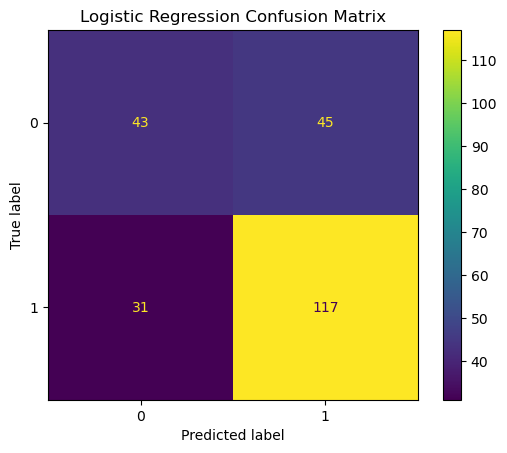

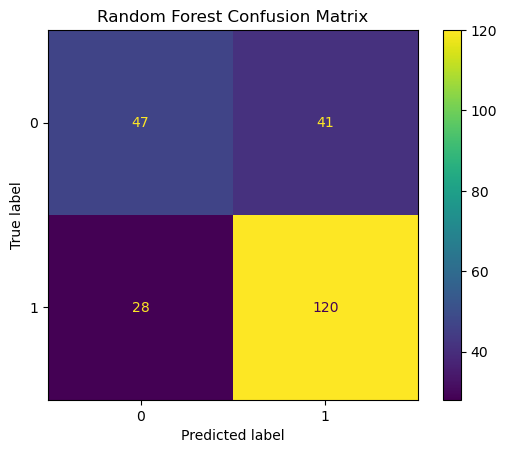

In [197]:
#confusion matrices
#Shows exactly what my model got right and wrong
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [198]:
#Cross validation- testing how consistently they perform
from sklearn.model_selection import cross_val_score

logistic_cv = cross_val_score(
    logistic_model,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

forest_cv = cross_val_score(
    random_forest,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Logistic Regression CV F1 scores:")
print(logistic_cv)

print("Mean:", logistic_cv.mean())

print("\nRandom Forest CV F1 scores:")
print(forest_cv)

print("Mean:", forest_cv.mean())

Logistic Regression CV F1 scores:
[0.8        0.80645161 0.8        0.8046875  0.76984127]
Mean: 0.7961960765488991

Random Forest CV F1 scores:
[0.75502008 0.808      0.78599222 0.79069767 0.77470356]
Mean: 0.782882705990195


In [199]:
#hyperparameter tuning
#imporoving the Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}
0.798494237982226


In [200]:
#Getting my final model
best_model = grid_search.best_estimator_
final_pred = best_model.predict(x_test)
print("Final Model Performance")

print("Accuracy:",
      accuracy_score(y_test, final_pred))

print("Precision:",
      precision_score(y_test, final_pred))

print("Recall:",
      recall_score(y_test, final_pred))

print("F1 Score:",
      f1_score(y_test, final_pred))

Final Model Performance
Accuracy: 0.6694915254237288
Precision: 0.6944444444444444
Recall: 0.8445945945945946
F1 Score: 0.7621951219512195


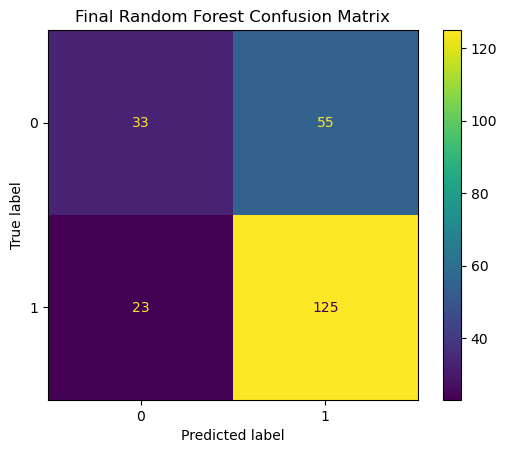

In [201]:
#final confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred
)

plt.title("Final Random Forest Confusion Matrix")
plt.show()

In [202]:
#Calculate your final metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Final Model Performance")
print("-----------------------")

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1 Score:", f1_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

Final Model Performance
-----------------------
Accuracy: 0.6694915254237288
Precision: 0.6944444444444444
Recall: 0.8445945945945946
F1 Score: 0.7621951219512195

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.38      0.46        88
           1       0.69      0.84      0.76       148

    accuracy                           0.67       236
   macro avg       0.64      0.61      0.61       236
weighted avg       0.66      0.67      0.65       236



In [203]:
#Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

final_prob = best_model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, final_prob)

print("Final ROC-AUC:", roc_auc)

Final ROC-AUC: 0.7248925061425061


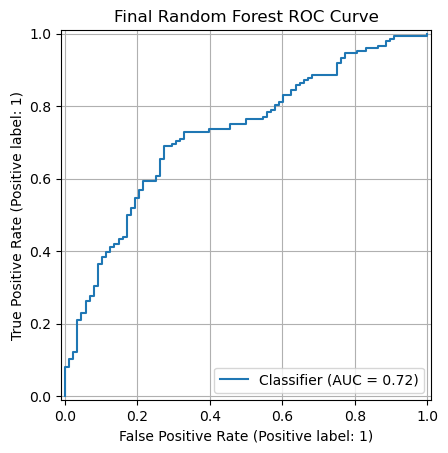

In [204]:
#Plot ROC curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    final_prob
)

plt.title("Final Random Forest ROC Curve")
plt.grid()
plt.show()

In [205]:
#Look at feature importance
# Get the trained Random Forest
rf_model = best_model.named_steps["model"]

# Get the preprocessing step
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,numeric__credit_score,0.329714
7,numeric__late_payments_last_12m,0.178521
4,numeric__loan_amount_ksh,0.071249
9,numeric__savings_ksh,0.068897
8,numeric__debt_to_income_ratio,0.065649
0,numeric__age,0.061671
1,numeric__monthly_income_ksh,0.056427
2,numeric__employment_years,0.047740
6,numeric__existing_loans,0.020328
5,numeric__loan_term_months,0.020070


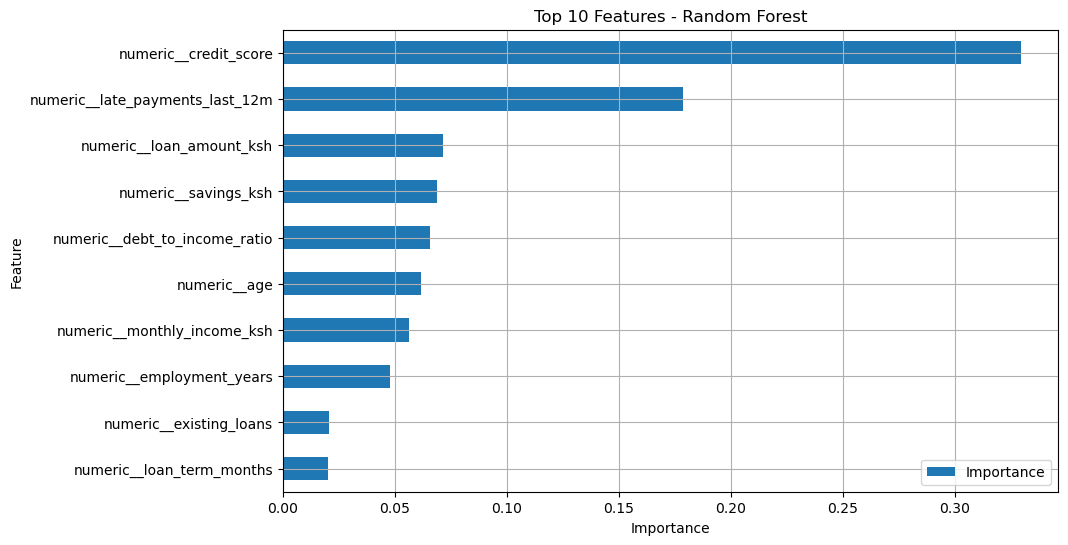

In [207]:
#visualization of feature importance
feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.grid()
plt.show()